---

# Bivariate Analysis

Bivariate Analysis involves analyzing two variables simultaneously to determine the empirical relationship, correlation, and pattern between them. It helps uncover dependencies and directional associations between features.

---

### Analysis Types & Visualization Toolkit

| Combination Type | Description | Preferred Visualizations / Statistical Tools |
| --- | --- | --- |
| **Numerical vs Numerical** | Measures correlation, linear trends, and continuous spread | Scatter Plot, Line Plot, Correlation Heatmap, 2D Hexbin |
| **Categorical vs Numerical** | Compares numerical distribution across distinct categories | Box Plot, Bar Plot (with Estimator), Violin Plot, KDE Plot (with `hue`) |
| **Categorical vs Categorical** | Evaluates frequency distribution and category associations | Crosstab Heatmap, Stacked Bar Chart, Grouped Countplot, Chi-Square Test |

---

### Core Objectives

* **Correlation Identification:** Understand whether one feature increases, decreases, or stays constant as another changes.
* **Target Feature Interaction:** Analyze how independent features influence the target variable (e.g., `Age` vs `Survived`).
* **Feature Selection:** Filter out redundant/multicollinear features and select high-impact predictors for machine learning pipelines.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1- First Data Set 

In [53]:
tips = sns.load_dataset('tips')
tips.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Seaborn `tips` Dataset Overview

The `tips` dataset contains dining records from a restaurant, recording customer spending patterns, tip amounts, and demographic/transaction attributes.

---

### Dataset Attributes

| Column | Data Type | Variable Type | Description |
| --- | --- | --- | --- |
| **`total_bill`** | Float | Numerical (Continuous) | Total bill amount in dollars (including food and drinks) |
| **`tip`** | Float | Numerical (Continuous) | Tip amount given to the staff |
| **`sex`** | Category | Categorical (Binary) | Gender of the bill payer (`Male`, `Female`) |
| **`smoker`** | Category | Categorical (Binary) | Whether the party was in a smoking section (`Yes`, `No`) |
| **`day`** | Category | Categorical (Nominal) | Day of the week (`Thur`, `Fri`, `Sat`, `Sun`) |
| **`time`** | Category | Categorical (Binary) | Meal time (`Lunch`, `Dinner`) |
| **`size`** | Integer | Numerical (Discrete) | Number of people dining at the table |

---

### Key Bivariate Analysis Ideas

* **Numerical vs Numerical:**
* `total_bill` vs `tip` $\rightarrow$ `sns.scatterplot()` to measure tipping percentage trends.


* **Categorical vs Numerical:**
* `day` vs `total_bill` $\rightarrow$ `sns.boxplot()` or `sns.barplot()` to compare spending by weekday/weekend.
* `sex` vs `tip` $\rightarrow$ `sns.violinplot()` to check tipping behavior differences across gender.


* **Categorical vs Categorical:**
* `smoker` vs `time` $\rightarrow$ `pd.crosstab()` with `sns.heatmap()` to evaluate dining time distribution for smokers.

## 2- Second data Set - Titanic

In [54]:
titanic = pd.read_csv("All_dataSet/20_Titanic-Dataset.csv")
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3- Third Dataset - flights

The `flights` dataset contains monthly passenger numbers for commercial airlines over a multi-year period (1949 to 1960), making it ideal for time series and bivariate/multivariate pattern analysis.

```python
import seaborn as sns

flights = sns.load_dataset('flights')
flights.head()

```

---

### Dataset Attributes

| Column | Data Type | Variable Type | Description |
| --- | --- | --- | --- |
| **`year`** | Integer / Category | Numerical / Temporal | The year of observation (1949 to 1960) |
| **`month`** | Category | Categorical (Ordinal) | The month of the flight (`Jan` through `Dec`) |
| **`passengers`** | Integer | Numerical (Discrete) | Total number of airline passengers (in thousands) |

---

### Key Analysis & Visualization Ideas

* **Pivot Table with Heatmap (Classic Use Case):**
* Reshape data using `flights.pivot(index='month', columns='year', values='passengers')` and plot with `sns.heatmap(cmap='Blues')` to observe seasonal passenger surges over the years.


* **Line Plot with Confidence Interval / Aggregation:**
* `sns.lineplot(x='year', y='passengers', data=flights)` to visualize the overarching annual growth trend.


* **Monthly Seasonality (Categorical vs Numerical):**
* `sns.barplot(x='month', y='passengers', data=flights)` or `sns.boxplot(x='month', y='passengers', data=flights)` to identify peak travel months (e.g., summer holidays).

In [55]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


# 4- Fourth Dataset - iris

The `iris` dataset is a classic multivariate dataset in machine learning and statistics, recording morphological measurements across three distinct species of Iris flowers.

```python
import seaborn as sns

iris = sns.load_dataset('iris')
iris.head()

```

---

### Dataset Attributes

| Column | Data Type | Variable Type | Description |
| --- | --- | --- | --- |
| **`sepal_length`** | Float | Numerical (Continuous) | Length of the sepal (outer parts of flower) in cm |
| **`sepal_width`** | Float | Numerical (Continuous) | Width of the sepal in cm |
| **`petal_length`** | Float | Numerical (Continuous) | Length of the petal (inner petals) in cm |
| **`petal_width`** | Float | Numerical (Continuous) | Width of the petal in cm |
| **`species`** | Object / Category | Categorical (Nominal) | Iris flower species (`setosa`, `versicolor`, `virginica`) |

---

### Key Bivariate & Multivariate Analysis Ideas

* **Numerical vs Numerical with Categorical Hue:**
* `sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=iris)` to see how cleanly species separate based on petal dimensions.


* **Categorical vs Numerical:**
* `sns.boxplot(x='species', y='petal_length', data=iris)` to compare the spread and median of features across species.


* **All-in-One Pairwise Analysis (Best Practice):**
* `sns.pairplot(iris, hue='species')` to generate a full grid of bivariate scatter plots alongside univariate KDE distributions.

In [68]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 5- Types of Bivariate Analysis by Variable Combination

Data types ke combination ke base par Bivariate Analysis ko teen major categories me divide kiya jata hai:

---

### 1. Numerical vs Numerical Analysis

Jab dono variables continuous ya discrete numbers hon. Iska primary goal correlation, spread, aur linear/non-linear patterns check karna hota hai.

* **Main Objective:** Check karna ki ek number ke badhne par doosra number badhta hai, ghatta hai, ya koi relation nahi hai (Correlation: $-1$ to $+1$).
* **Best Visualizations:**
* **Scatter Plot (`sns.scatterplot`):** Individual data points ki distribution dekhne ke liye.
* **Line Plot (`sns.lineplot`):** Continuous trends ya time-series patterns ke liye.
* **Joint Plot / Hexbin (`sns.jointplot`):** Data points ki density aur marginal distribution sath me dekhne ke liye.
* **Correlation Heatmap (`sns.heatmap(df.corr())`):** Pairwise correlation scores summarize karne ke liye.


* **Examples:**
* `total_bill` vs `tip` (Tips dataset)
* `petal_length` vs `petal_width` (Iris dataset)
* `Age` vs `Fare` (Titanic dataset)



---

### 2. Categorical vs Numerical Analysis

Jab ek variable discrete categories/labels ho aur doosra variable numeric values contain karta ho. Iska goal different groups ke beech numerical distribution aur statistical metrics (mean, median, spread) compare karna hota hai.

* **Main Objective:** Har category group ke numerical behavior, outliers, aur central tendency me difference find karna.
* **Best Visualizations:**
* **Box Plot (`sns.boxplot`):** Median, quartiles ($Q_1, Q_3$), aur outliers compare karne ke liye.
* **Violin Plot (`sns.violinplot`):** Boxplot ke sath-sath density/KDE distribution dekhne ke liye.
* **Bar Plot with Estimator (`sns.barplot`):** Har group ka aggregate mean/median with confidence interval dekhne ke liye.
* **Overlapping KDE / Histplot (`sns.kdeplot(hue='...')` ya `sns.displot`):** Groups ki smooth probability distribution compare karne ke liye.


* **Examples:**
* `species` vs `sepal_length` (Iris dataset)
* `day` vs `total_bill` (Tips dataset)
* `Pclass` vs `Age` / `Sex` vs `Fare` (Titanic dataset)



---

### 3. Categorical vs Categorical Analysis

Jab dono variables groups, labels, ya textual classes hon. Iska goal classes ke beech ki frequency distribution, cross-tabulation, aur statistical dependency check karna hota hai.

* **Main Objective:** Check karna ki kya ek category ka distribution doosri category par dependent hai.
* **Best Visualizations & Statistical Tools:**
* **Grouped / Clustered Countplot (`sns.countplot(x='...', hue='...')`):** Sub-groups ke direct counts compare karne ke liye.
* **Contingency Table / Crosstab Heatmap (`pd.crosstab()` + `sns.heatmap()`):** 2D matrix me frequencies ya percentage normalization dekhne ke liye.
* **Stacked Bar Chart (`ct.plot(kind='bar', stacked=True)`):** Proportions compare karne ke liye.
* **Statistical Test:** **Chi-Square Test of Independence** ($p\text{-value} < 0.05$).


* **Examples:**
* `Sex` vs `Survived` (Titanic dataset)
* `smoker` vs `time` (Tips dataset)
* `Pclass` vs `Embarked` (Titanic dataset)

## 1. Scatterplot (Numerical - Numerical)

```python
# Tips dataset example (total_bill vs tip with gender hue)
sns.scatterplot(
    x='total_bill', 
    y='tip', 
    data=tips, 
    hue='sex', 
    style='smoker', 
    size='size'
)

```

---

### Parameters Explanation

* **`x='total_bill'`**: X-axis par pehla Continuous Numerical variable set karta hai (independent variable / base measurement).
* **`y='tip'`**: Y-axis par doosra Continuous Numerical variable set karta hai (dependent variable / target value) jiska correlation check karna hota hai.
* **`data=tips`**: Us DataFrame ka reference jisme yeh saare columns exist karte hain.
* **`hue='sex'`**: Data points ko ek categorical column (jaise `Male`, `Female`) ke base par alag-alag **colors** me divide karta hai.
* **`style='smoker'`**: Data points ko kisi categorical variable ke base par alag-alag **marker shapes** (jaise dot `o`, cross `x`) me display karta hai.
* **`size='size'`**: Kisi numerical ya ordinal variable ke magnitude ke according points ke **dot size** ko scale karta hai (jaise badi party size ke liye bada dot).

---

### Other Important Parameters (Optional)

* **`alpha=0.7`**: Points ki transparency set karta hai (0 se 1 ke beech), taaki overlapping points clear dikhein.
* **`palette='coolwarm'`**: Color theme/palette change karne ke liye.
* **`sizes=(20, 200)`**: `size` parameter ke minimum aur maximum marker size ki range define karta hai.
* **`legend='full'`**: Legend ke display behavior ko control karne ke liye.

<Axes: xlabel='total_bill', ylabel='tip'>

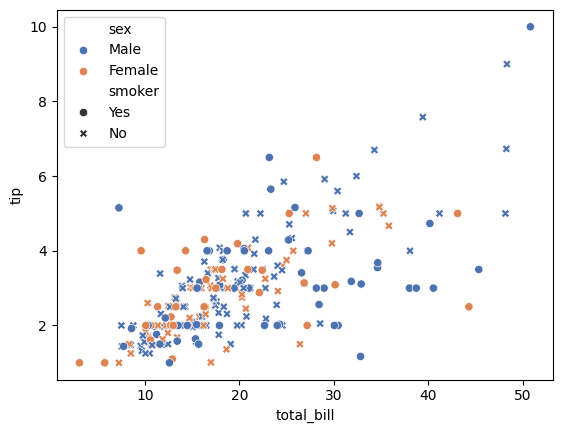

In [56]:
#sns.scatterplot(x='total_bill', y='tip', data=tips)
sns.scatterplot(x='total_bill', y='tip', data=tips,hue='sex',style='smoker',sizes=(20,200),palette='deep')

## 2. Bar Plot (Numerical - Categorical)

```python
# Titanic dataset example (Pclass vs Age with gender hue)
sns.barplot(
    x='Pclass', 
    y='Age', 
    data=df, 
    hue='Sex', 
    estimator='mean'
)

```

---

### Parameters Explanation

* **`x='Pclass'`**: X-axis par Categorical variable set karta hai. Ye data ko discrete groups/classes me divide karta hai.
* **`y='Age'`**: Y-axis par Numerical variable set karta hai jiska aggregate metric (jaise mean ya median) calculate karke bar ki height decide hoti hai.
* **`data=df`**: Us DataFrame ka reference jisme yeh saare columns maujood hain.
* **`hue='Sex'`**: Bars ko sub-categories (jaise `male` aur `female`) me split karke alag-alag colors me side-by-side display karta hai.
* **`estimator='mean'`**: Ye decide karta hai ki categorical groups ke numerical data par kaunsa statistical calculation apply hoga (by default Seaborn me `mean` hi hota hai).

---

### Other Important Parameters (Optional)

* **`estimator=np.median`**: Agar data me heavy outliers hon, toh mean ki jagah median use karne ke liye (`import numpy as np` ke sath).
* **`errorbar=None`** ya **`ci=None`**: Bar ke upar aane wali black vertical line (confidence interval / error bar) ko hatane ke liye.
* **`palette='Blues'`**: Bars ka color scheme ya color theme set karne ke liye.
* **`order=[3, 1, 2]`**: X-axis par categories ka display order manually decide karne ke liye.

<Axes: xlabel='Pclass', ylabel='Fare'>

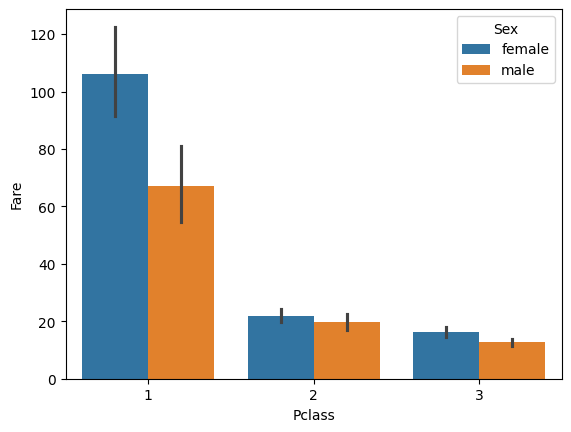

In [57]:
sns.barplot(x=titanic['Pclass'], y=titanic['Fare'], hue= titanic['Sex'],)

## 3. Box Plot (Numerical - Categorical)

```python
# Titanic dataset example (Sex vs Age distribution with Survived hue)
sns.boxplot(
    x='Sex', 
    y='Age', 
    data=df, 
    hue='Survived', 
    palette='Set2'
)

```

---

### Parameters Explanation

* **`x='Sex'`**: X-axis par Categorical column set karta hai. Ye data ko main groups (jaise `Male` aur `Female`) me divide karta hai.
* **`y='Age'`**: Y-axis par Numerical column set karta hai. Ye har group ke liye 5-number summary (Min, $Q_1$, Median, $Q_3$, Max) aur outliers ki distribution draw karta hai.
* **`data=df`**: Us DataFrame ka reference jisme saare columns present hain. Isse baar-baar `df['Sex']` likhne ki zaroorat nahi padti.
* **`hue='Survived'`**: Har category ke andar ek aur sub-group create karta hai (jaise Male ke andar Survived: `0` aur `1`). Isse do alag-alag color ke boxes sath-sath compare ho jaate hain.
* **`palette='Set2'`**: Seaborn ka color theme define karta hai, jisse plot clean aur visually distinct dikhta hai.

---

### Other Important Parameters (Optional)

* **`order=['male', 'female']`**: X-axis par categories ka display sequence customize karne ke liye.
* **`width=0.5`**: Box ki chaurai (width) ko adjust karne ke liye.
* **`showmeans=True`**: Box ke andar median ke sath mean value ka point marker show karne ke liye.
* **`fliersize=3`**: Outlier points ke dot size ko chhota ya bada karne ke liye.

<Axes: xlabel='Sex', ylabel='Age'>

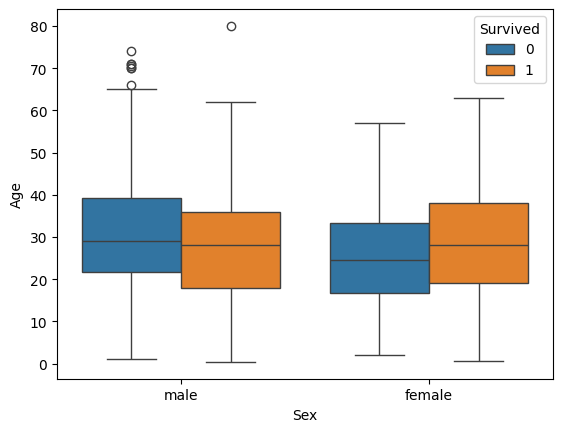

In [58]:
sns.boxplot(x=titanic["Sex"], y=titanic["Age"], hue=titanic["Survived"])

## 4. Distplot / KDE Plot (Numerical - Categorical)

```python
# Titanic dataset example (Age distribution comparison by Survived)
sns.kdeplot(
    x='Age', 
    data=df, 
    hue='Survived', 
    fill=True, 
    common_norm=False
)

```

---

### Parameters Explanation

* **`x='Age'`**: Numerical continuous column set karta hai jiska probability density curve calculate aur plot karna hai.
* **`data=df`**: Us DataFrame ka reference jisme columns maujood hain.
* **`hue='Survived'`**: Numerical variable ki distribution ko categorical classes (jaise `0` = Died, `1` = Survived) ke basis par alag-alag colored curves me split karta hai.
* **`fill=True`**: Curve ke niche ke area ko color se fill (shade) karta hai taaki dono distributions ka comparison visually clear ho sake.
* **`common_norm=False`**: Har hue group ke area ko independently normalize (total area = 1) karta hai. Isse unbalanced classes hone par bhi distribution shapes easily compare ho jaate hain.

---

### Other Important Parameters (Optional)

* **`alpha=0.4`**: Filled color shade ki transparency set karta hai taaki overlapping regions clear dikhein.
* **`palette='coolwarm'`**: Density curves aur fills ke color palette ko customize karne ke liye.
* **`multiple='stack'`** ya **`multiple='layer'`**: Agar multiple density curves aapas me overlap ho rahe hon, toh unhe stack ya layer mode me render karne ke liye.
* **`bw_adjust=0.5`**: Bandwidth adjust karta hai (smoothing control karne ke liye — chhota number zyada details/peaks dikhata hai, bada number smoother curve banata hai).

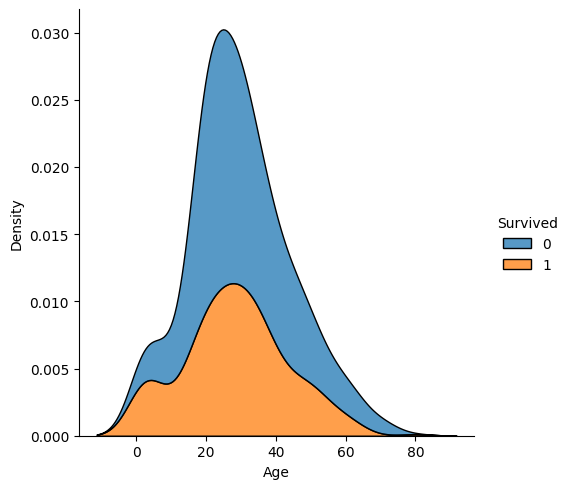

In [59]:
sns.displot(x=titanic["Age"], hue=titanic["Survived"], kind="kde", fill=True, multiple="stack")

## 5. Heatmap (Categorical - Categorical)

```python
# Titanic dataset example (Pclass vs Sex frequency table)
import pandas as pd
import seaborn as sns

# Step 1: Contingency Matrix create karna
ct = pd.crosstab(df['Pclass'], df['Sex'])

# Step 2: Heatmap plot karna
sns.heatmap(
    data=ct, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True
)

```

---

### Parameters Explanation

* **`data=ct`**: 2D cross-tabulation table ya matrix jo row aur column categories ke intersection counts hold karti hai.
* **`annot=True`**: Har cell ke andar exact numerical value (count/percentage) text ke roop me print karta hai.
* **`fmt='d'`**: Annotation numbers ka format define karta hai (`'d'` integer values ke liye aur `'.2f'` float/percentage ke liye use hota hai).
* **`cmap='Blues'`**: Heatmap ke color map ko set karta hai (e.g., `'Blues'`, `'viridis'`, `'coolwarm'`), jisme count badhne par color intensity badhti hai.
* **`cbar=True`**: Side me color bar (legend) display karta hai jo color intensity aur values ka scale represent karta hai.

---

### Other Important Parameters (Optional)

* **`linewidths=0.5`**: Grid cells ke beech patli boundary line draw karta hai taaki blocks aapas me merge na hon.
* **`linecolor='white'`**: Grid lines ka border color set karne ke liye.
* **`vmin` & `vmax**`: Color map ke minimum aur maximum scale bounds manually fix karne ke liye.
* **`normalize='index'` / `normalize='columns'` (in `pd.crosstab`)**: Raw counts ki jagah row-wise ya column-wise percentage calculate karke show karne ke liye (tab `fmt='.2%'` ya `fmt='.2f'` use karte hain).

In [60]:
ct = pd.crosstab(index=titanic['Pclass'], columns=titanic['Survived'])

## ⬆️ `pd.crosstab()` Overview

`pd.crosstab()` categorical variables ke frequency distribution ko **Contingency Matrix (2D Table)** ke roop me summarize karta hai.

```python
pd.crosstab(index=titanic['Pclass'], columns=titanic['Survived'])

```

---

### Key Components

* **`index` (Rows):** Pehla variable jo table ki rows decide karta hai (e.g., `Pclass`: 1, 2, 3).
* **`columns` (Columns):** Doosra variable jo table ke columns decide karta hai (e.g., `Survived`: 0 = Died, 1 = Survived).

---

### Output Structure

| `Pclass` | `0` (Died) | `1` (Survived) |
| --- | --- | --- |
| **1** | 80 | 136 |
| **2** | 97 | 87 |
| **3** | 372 | 119 |

---

### Useful Parameters

* **`normalize='index'` / `'columns'`:** Raw counts ki jagah row-wise ya column-wise percentages calculate karta hai.
* **`margins=True`:** Rows aur columns ke end me grand total (`All`) add karta hai.

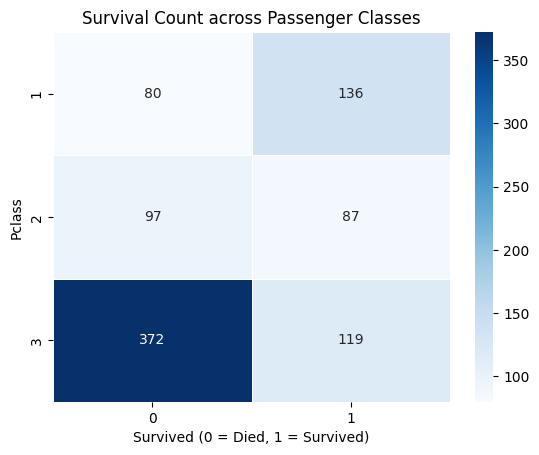

In [61]:
sns.heatmap(data=ct, annot=True, fmt='d', cmap='Blues',linewidths=0.5,linecolor='white')
plt.title('Survival Count across Passenger Classes')
plt.xlabel('Survived (0 = Died, 1 = Survived)')
plt.ylabel('Pclass')
plt.show()

# GroupBy in Pandas

* **Concept:** Works on the **Split-Apply-Combine** principle.
* **Split:** Categorical column ke base par data ko distinct groups me divide karta hai.
* **Apply:** Har group par statistical operations (`mean()`, `sum()`, `count()`, `median()`) execute karta hai.
* **Combine:** Saare calculated results ko single summary table me aggregate karta hai.
* **Syntax:** `df.groupby('Categorical_Col')['Numerical_Col'].mean()`

In [62]:
titanic.groupby('Pclass')['Survived'].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [63]:
titanic.groupby('Pclass')['Survived'].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [64]:
titanic.groupby('Embarked')['Survived'].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

# 6. Clustermap (Categorical - Categorical)

`sns.clustermap()` cross-tabulated categorical data par hierarchical clustering apply karta hai aur similar patterns wali rows aur columns ko aapas me group (cluster) karke visualize karta hai.

```python
import pandas as pd
import seaborn as sns

# Step 1: Contingency table create karna
ct = pd.crosstab(titanic['Parch'], titanic['Survived'])

# Step 2: Clustermap plot karna
sns.clustermap(
    data=ct, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    standard_scale=None
)

```

---

### Parameters Explanation

* **`data=ct`**: 2D cross-tabulation table ya numerical matrix jiske rows aur columns ko cluster karna hai.
* **`annot=True`**: Matrix ke har block/cell ke andar numerical values display karta hai.
* **`fmt='d'`**: Annotation numbers ko integer decimal format me represent karta hai.
* **`cmap='Blues'`**: Clusters aur density intensity ko represent karne ke liye color palette set karta hai.
* **`standard_scale=None`**: Columns ya rows ko scale karne ke liye (`0` for rows, `1` for columns); defaults to raw counts if `None`.

---

### Other Important Parameters (Optional)

* **`col_cluster=False` / `row_cluster=False**`: Kisi specific axis (rows ya columns) par tree/clustering disable karne ke liye.
* **`metric='euclidean'`**: Distance calculate karne ka mathematical method (e.g., `'euclidean'`, `'correlation'`).
* **`method='average'`**: Linkage method jo clusters banate waqt use hoti hai (e.g., `'single'`, `'complete'`, `'average'`).
* **`figsize=(8, 6)`**: Output plot ka size set karne ke liye.

In [65]:
pd.crosstab(index=titanic['SibSp'], columns=titanic['Survived'])

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


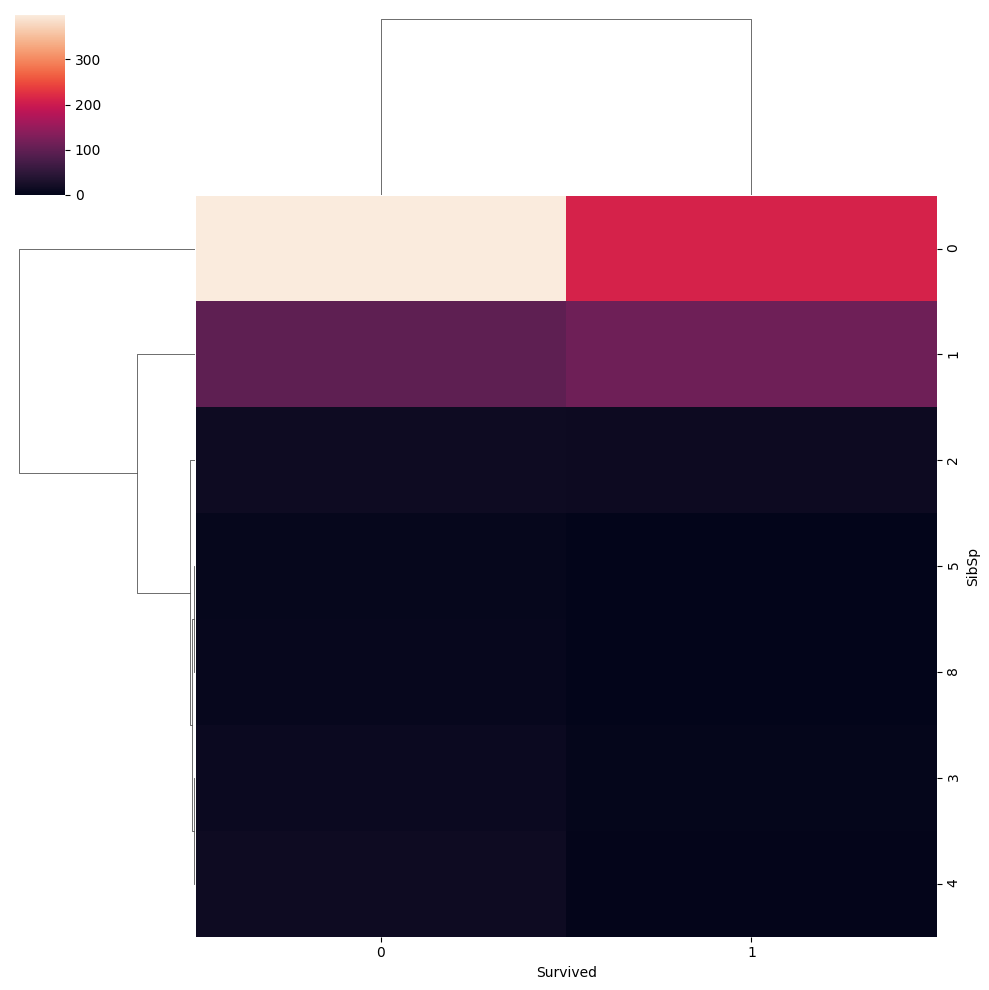

In [66]:
sns.clustermap(pd.crosstab(index=titanic['SibSp'], columns=titanic['Survived']))

##
⬆️  Clustermap in Seaborn

* **Concept:** Heatmap ke sath **Hierarchical Clustering** perform karke similar rows aur columns ko aapas me group karta hai.
* **Tree Structure (Dendrogram):** Data points ke beech distance/similarity show karne ke liye axes par tree-like structure draw karta hai.
* **Syntax:** `sns.clustermap(pd.crosstab(df['col1'], df['col2']), annot=True, cmap='coolwarm')`

# 8. Pairplot (Numerical - Numerical with Categorical Hue)

`sns.pairplot()` dataset ke saare numerical features ke beech pairwise scatter plots aur diagonal par unka univariate distribution (histogram/KDE) ek grid matrix me plot karta hai.

```python
import seaborn as sns

# Iris dataset example
sns.pairplot(
    data=iris, 
    hue='species', 
    diag_kind='kde', 
    palette='Set2'
)

```

---

### Parameters Explanation

* **`data=iris`**: DataFrame jisme numerical aur categorical columns available hain.
* **`hue='species'`**: Grid ke sabhi plots ko categorical target classes ke according alag-alag colors me split karta hai.
* **`diag_kind='kde'`**: Diagonal graphs par distribution style decide karta hai (`'kde'` smooth density curves ke liye, `'hist'` histograms ke liye).
* **`palette='Set2'`**: Hue categories ke visual colors customize karne ke liye palette set karta hai.

---

### Other Important Parameters (Optional)

* **`vars=['sepal_length', 'petal_length']`**: Poore dataset ke bajay selected numerical columns par grid limit karne ke liye.
* **`corner=True`**: Duplicate upper triangle plots hata kar sirf lower half triangle plot karta hai.
* **`kind='reg'`**: Scatter points ke sath linear regression fit line draw karne ke liye.

---

### 3-Line Quick Summary

* **Concept:** Dataset ke har numerical variable pair ka correlation ek sath matrix grid me visualize karta hai.
* **Diagonal vs Off-Diagonal:** Diagonal par single variable ka distribution (KDE/Hist) aur baki grid me bivariate scatter plots dikhata hai.
* **Syntax:** `sns.pairplot(df, hue='target_column', corner=True)`

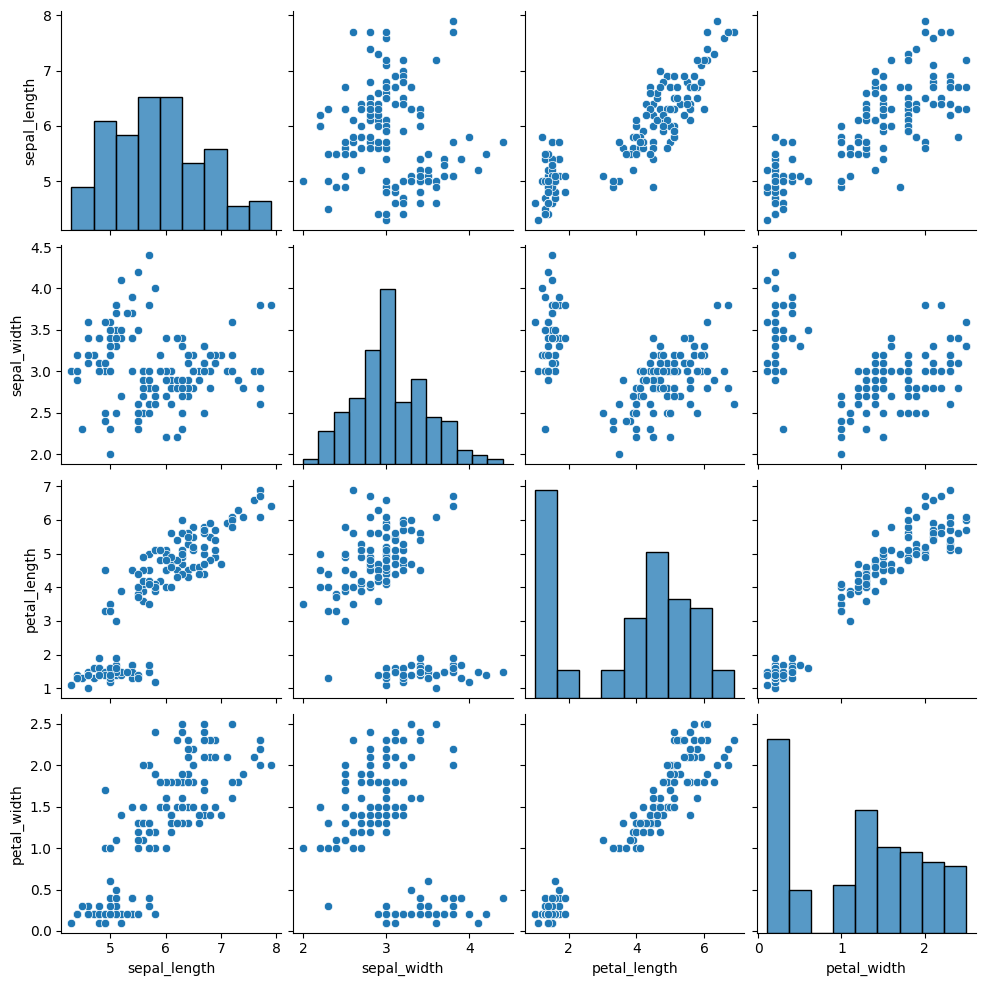

In [73]:
sns.pairplot(iris)

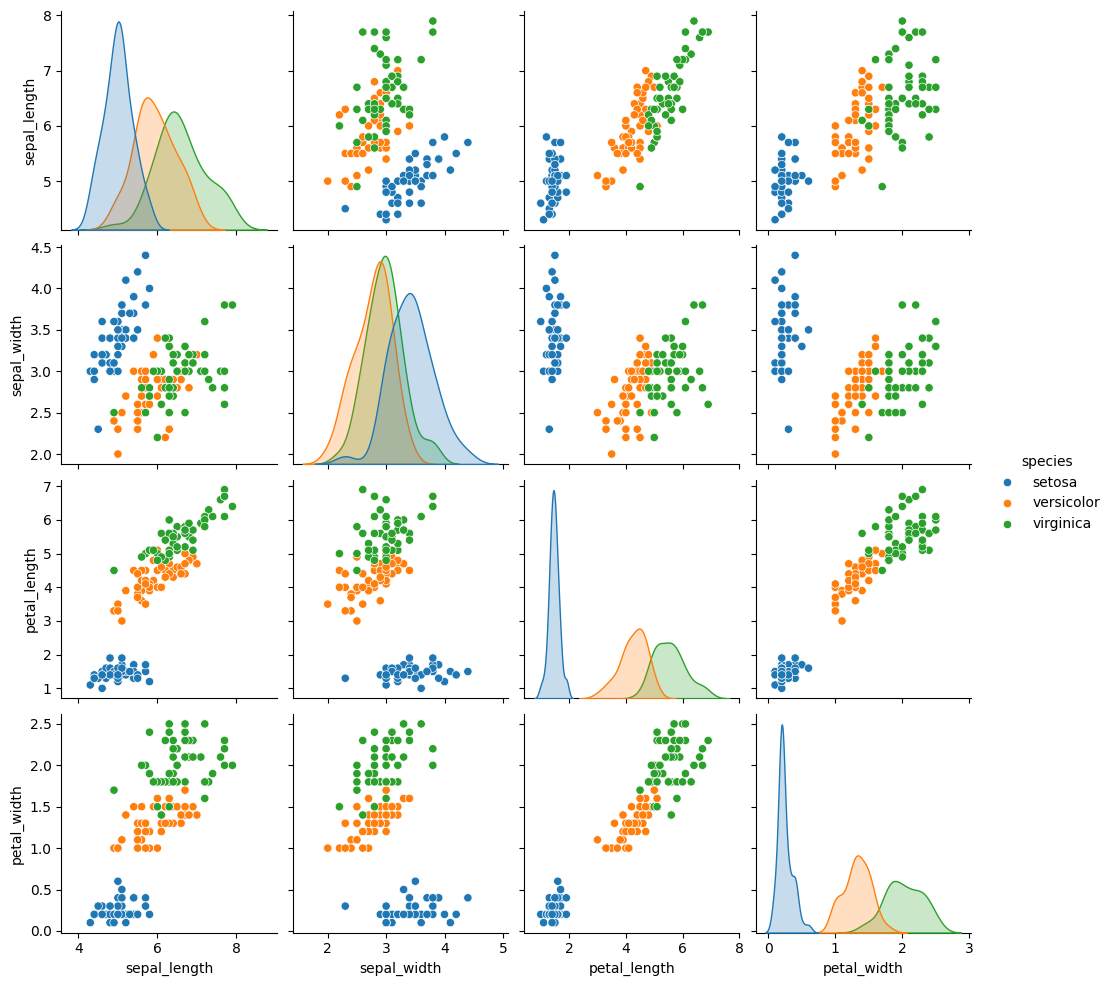

In [75]:
sns.pairplot(iris, hue="species")

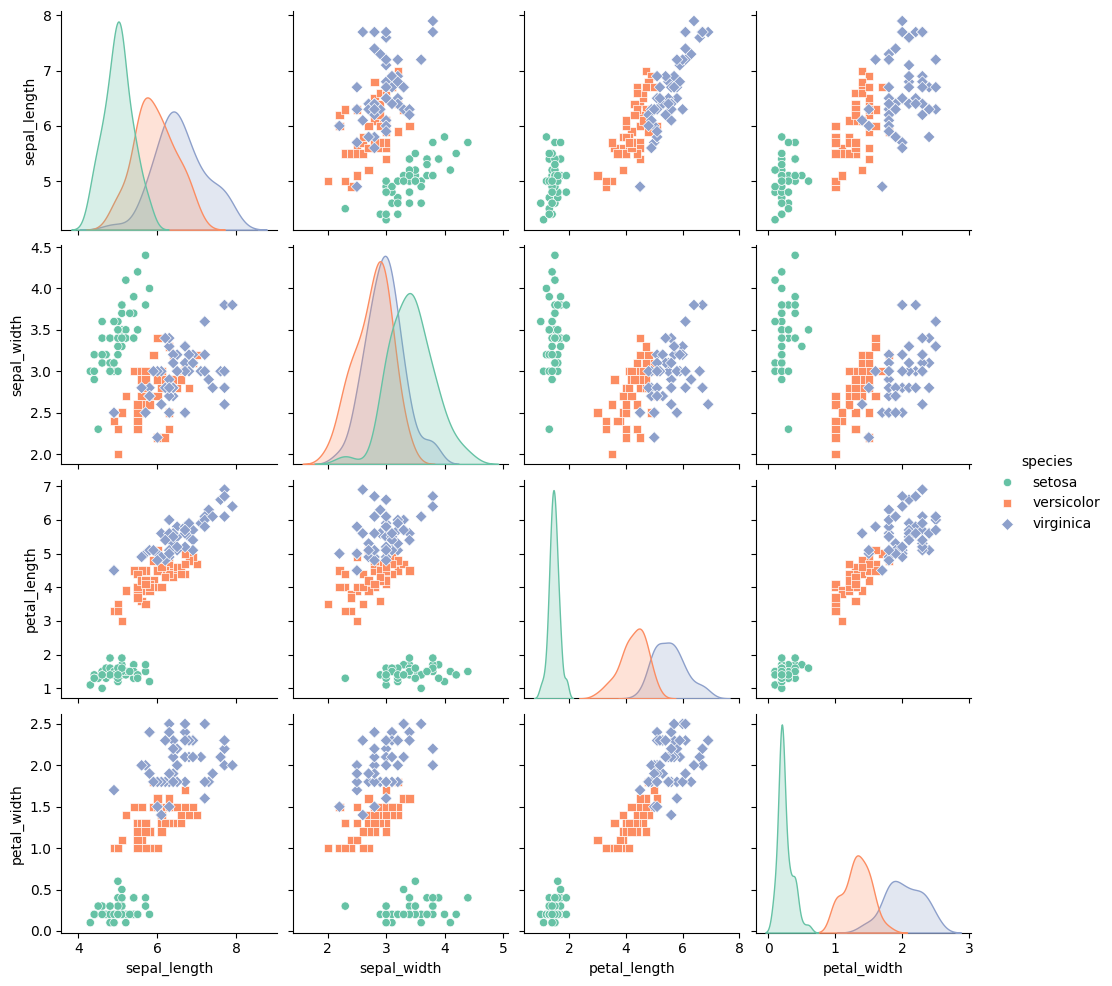

In [72]:
sns.pairplot(iris, hue='species', palette='Set2', markers=["o", "s", "D"])

# 8. Line Plot (Numerical - Numerical / Time Series)

`sns.lineplot()` continuous numerical variables ke beech ka trend aur continuous changes (jaise time series ya sequentially ordered data) visualize karne ke liye use hota hai.

```python
import seaborn as sns
import matplotlib.pyplot as plt

# Flights dataset example (Yearly passenger trend)
sns.lineplot(
    x='year', 
    y='passengers', 
    data=flights, 
    hue='month', 
    errorbar='ci'
)

```

---

### Parameters Explanation

* **`x='year'`**: X-axis par independent numerical ya continuous time variable (e.g., year, time, steps) set karta hai.
* **`y='passengers'`**: Y-axis par dependent numerical variable set karta hai jiska trend line ke through track karna hota hai.
* **`data=flights`**: Us DataFrame ka reference jisme columns maujood hain.
* **`hue='month'`**: Trend lines ko kisi categorical variable ke according multiple colored lines me split karta hai.
* **`errorbar='ci'`**: Multiple observations hone par mean value ke around shaded region (Confidence Interval) draw karta hai.

---

### Other Important Parameters (Optional)

* **`style='month'`**: Alag-alag categories ke liye solid, dashed, ya dotted lines use karne ke liye.
* **`markers=True`**: Line par data points par actual markers (`o`, `s`, etc.) display karne ke liye.
* **`estimator='mean'`**: Same X-value par multiple Y values hone par aggregation method decide karta hai (default is mean).
* **`errorbar=None`**: Shaded confidence interval band ko hatane ke liye.

---

### 3-Line Quick Summary

* **Concept:** Continuous sequential data aur time-series ke linear/non-linear trends track karne ke liye line draw karta hai.
* **Aggregation & CI:** Duplicate X-values ke liye automatically mean compute karke shaded confidence interval show karta hai.
* **Syntax:** `sns.lineplot(x='year', y='passengers', data=flights, hue='month')`

In [79]:
# Scater plot ke Sare point ko jod do toh wo hamra line plot ban jata hai
# Kab Use karna chhaiye = Jab  num time based ho like year , moths , days , etc 

new = flights.groupby('year')['passengers'].sum().reset_index()
new

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


<Axes: xlabel='year', ylabel='passengers'>

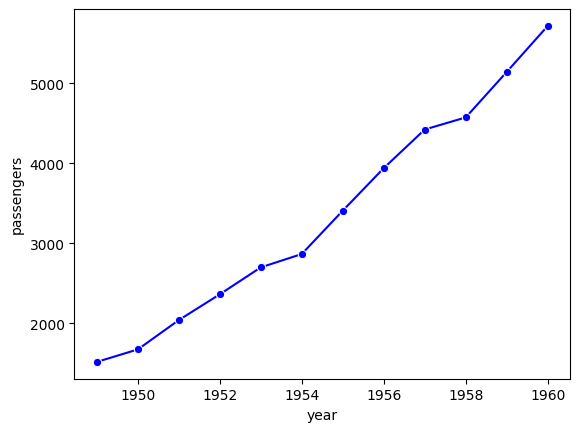

In [80]:
sns.lineplot(x='year', y='passengers', data=new, marker='o', color='blue')

In [82]:
# flight wale data set ke upper heatmape bana sakte ho 
flights.pivot_table(values='passengers', index='month', columns='year',observed=False)

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


<Axes: xlabel='year', ylabel='month'>

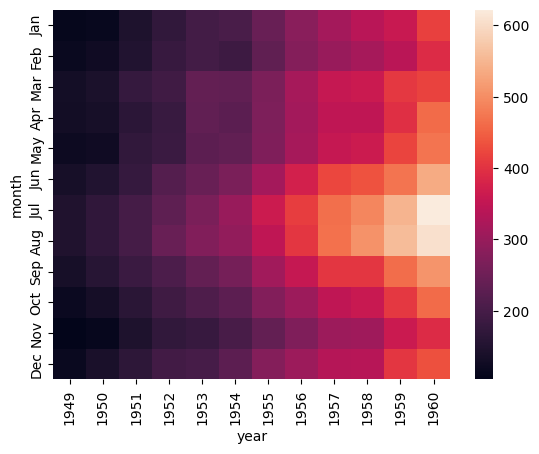

In [84]:
sns.heatmap(flights.pivot_table(values='passengers', index='month', columns='year',observed=False))

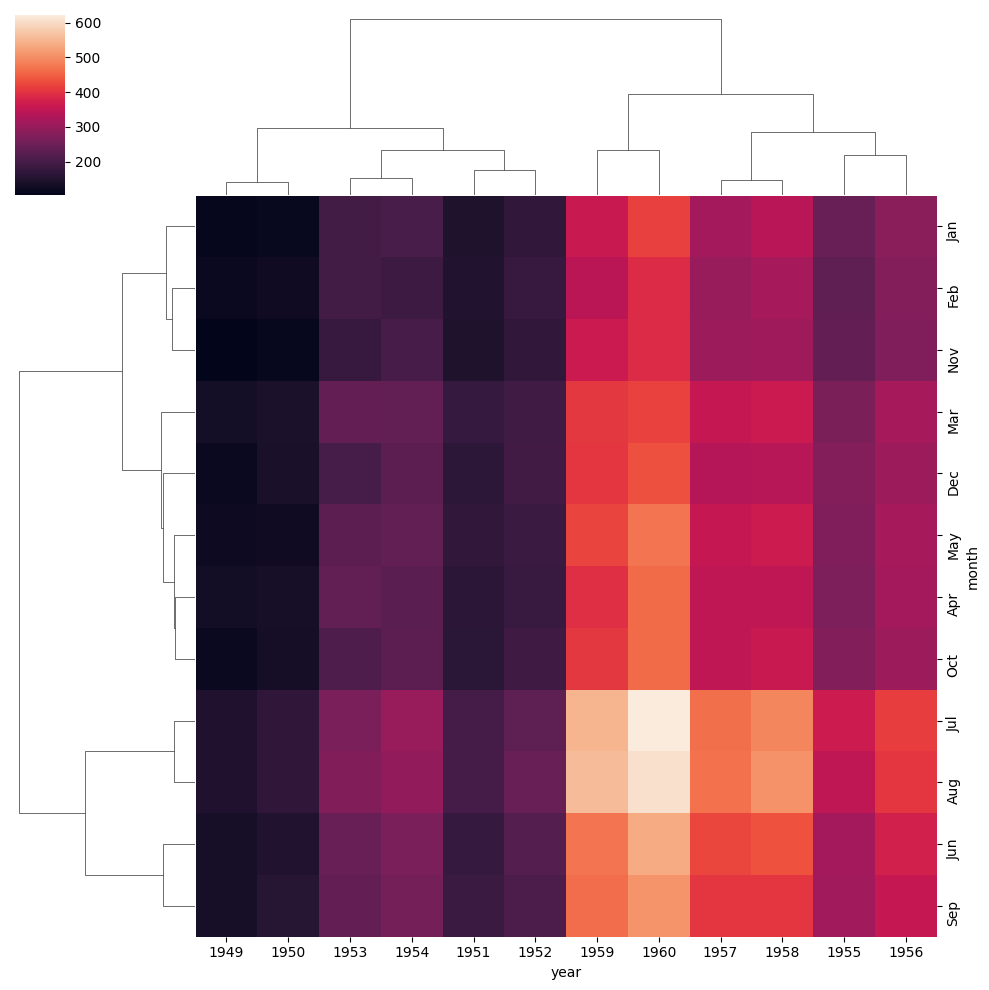

In [85]:
sns.clustermap(flights.pivot_table(values='passengers', index='month', columns='year',observed=False))